Shape: (14743, 10)

Data Types:
 time           int64
src_user         str
dst_user         str
src_pc           str
dst_pc           str
auth_type        str
logon_type       str
auth_orient      str
success          str
label          int64
dtype: object

First 5 rows:
      time    src_user    dst_user  src_pc dst_pc auth_type logon_type  \
0  150885   U620@DOM1   U620@DOM1  C17693  C1003      NTLM    Network   
1  151036   U748@DOM1   U748@DOM1  C17693   C305      NTLM    Network   
2  151648   U748@DOM1   U748@DOM1  C17693   C728      NTLM    Network   
3  151993  U6115@DOM1  U6115@DOM1  C17693  C1173      NTLM    Network   
4  153792   U636@DOM1   U636@DOM1  C17693   C294      NTLM    Network   

  auth_orient  success  label  
0       LogOn  Success      1  
1       LogOn  Success      1  
2       LogOn  Success      1  
3       LogOn  Success      1  
4       LogOn  Success      1  

Basic Statistics:
                time         label
count  1.474300e+04  14743.000000
mean   2

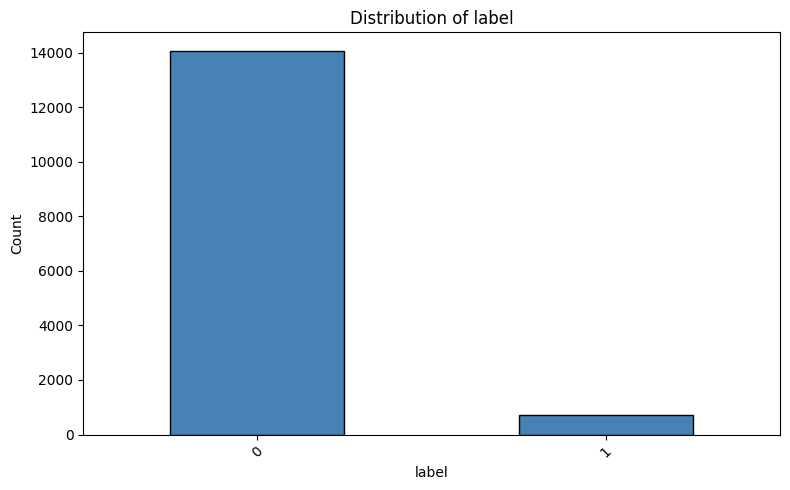


Numeric columns: ['time', 'label']


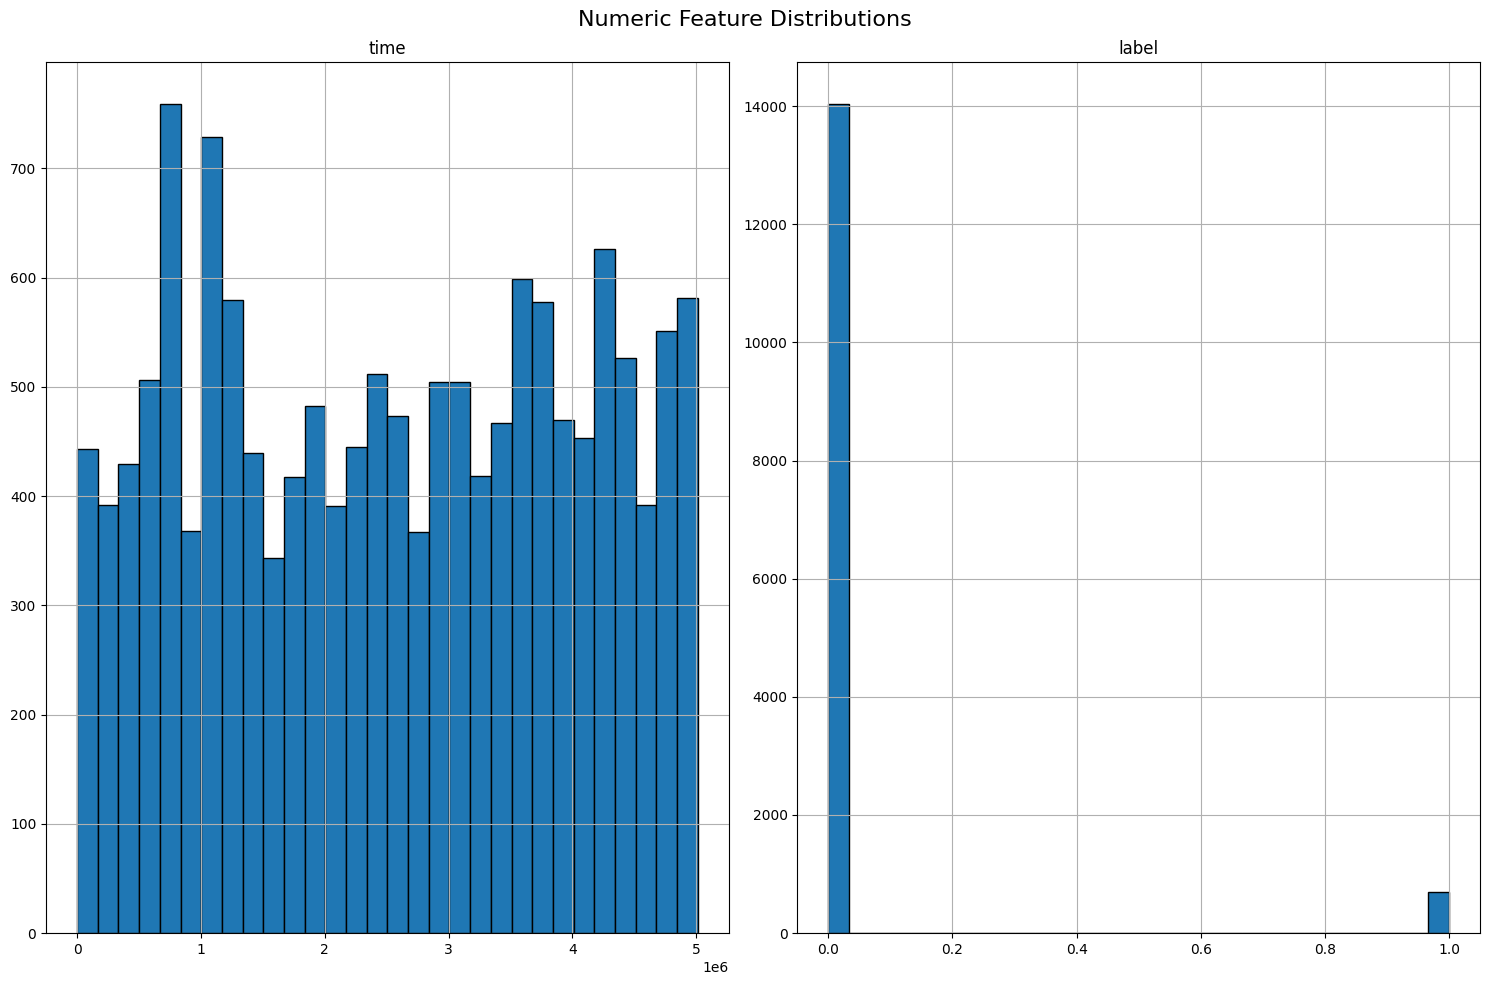

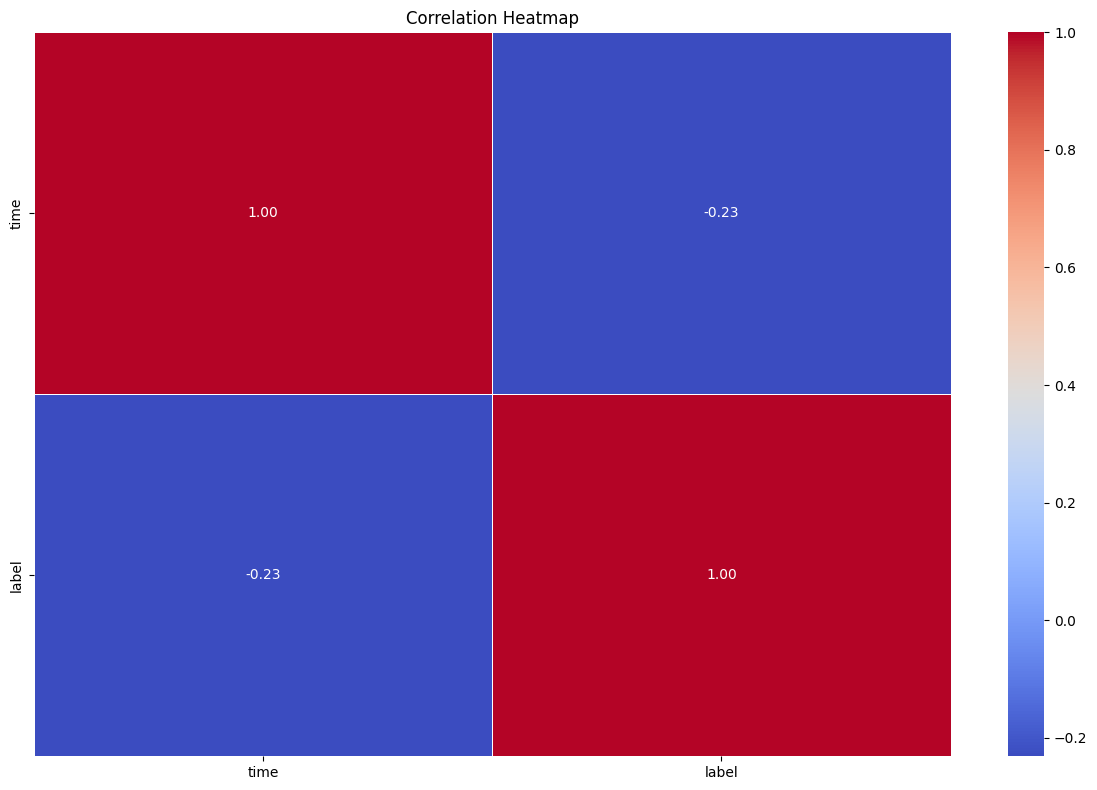


Categorical columns: ['src_user', 'dst_user', 'src_pc', 'dst_pc', 'auth_type', 'logon_type', 'auth_orient', 'success']

Value counts for 'src_user':
 src_user
U66@DOM1                264
ANONYMOUS LOGON@C586    243
U22@DOM1                241
C599$@DOM1              118
C1114$@DOM1             113
C743$@DOM1               90
C104$@DOM1               85
C585$@DOM1               82
C567$@DOM1               66
C1766$@DOM1              63
Name: count, dtype: int64


/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_40981/2514398063.py:53: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


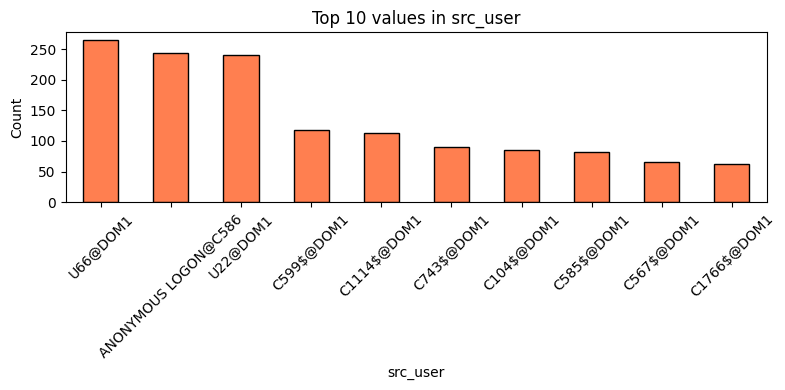


Value counts for 'dst_user':
 dst_user
U66@DOM1                264
ANONYMOUS LOGON@C586    243
U22@DOM1                241
C599$@DOM1              118
C1114$@DOM1             113
C743$@DOM1               90
C104$@DOM1               85
C585$@DOM1               82
C567$@DOM1               66
C1766$@DOM1              63
Name: count, dtype: int64


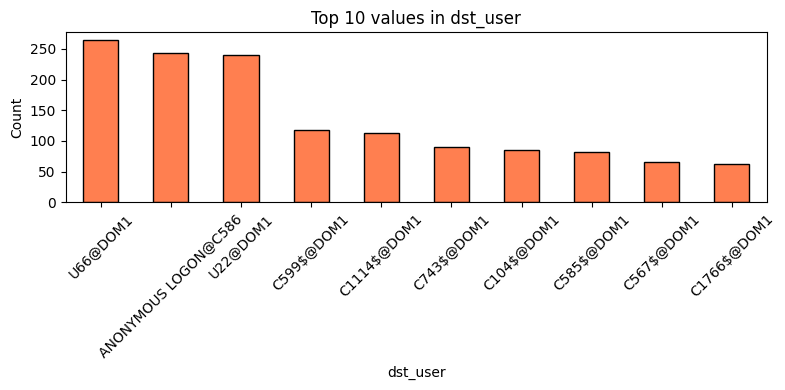


Value counts for 'src_pc':
 src_pc
C586      711
C17693    670
C467      555
C612      498
C529      492
C1065     489
C625      477
C457      416
C528      399
C2106     230
Name: count, dtype: int64


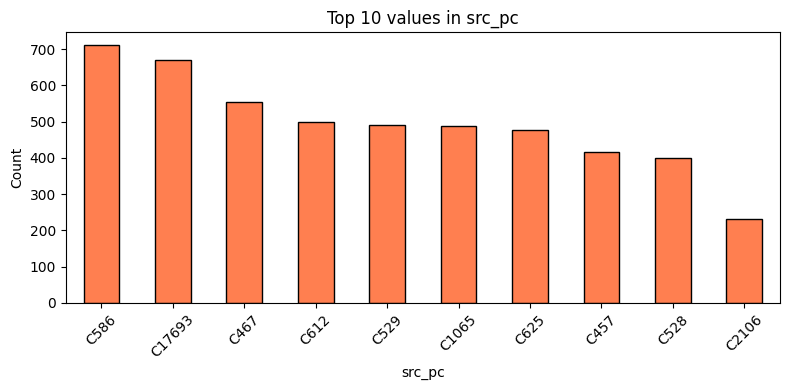


Value counts for 'dst_pc':
 dst_pc
C586     1613
C467     1035
C612     1017
C529      967
C1065     958
C625      926
C457      885
C528      782
C2106     455
C2162     325
Name: count, dtype: int64


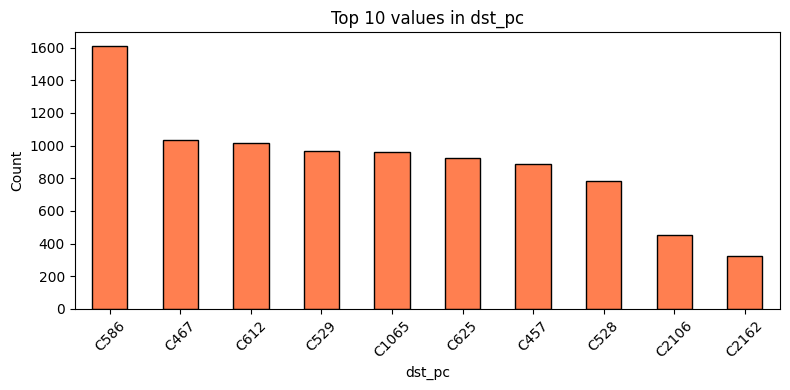


Value counts for 'auth_type':
 auth_type
?                                        7784
Kerberos                                 4835
NTLM                                     1368
Negotiate                                 742
MICROSOFT_AUTHENTICATION_PACKAGE_V1_0      11
MICROSOFT_AUTHENTICATION_PACKAGE            1
MICROSOFT_AUTHENTICATION_PACKAGE_V1_        1
MICROSOFT_AUTHENTICATION_PACKAGE_           1
Name: count, dtype: int64


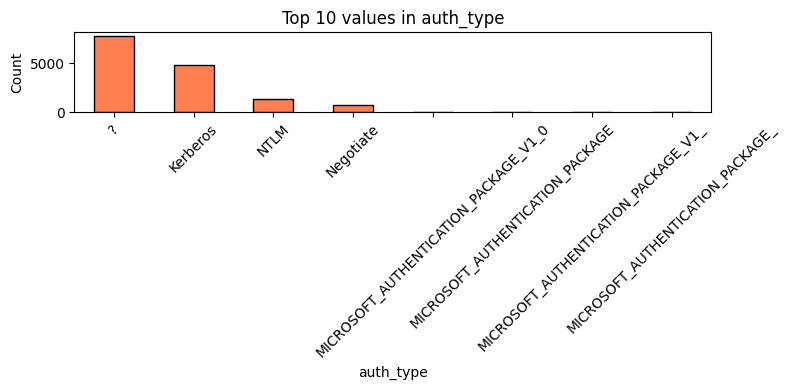

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('./data/cyber1/labeled_sample.csv')

# Basic info
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nBasic Statistics:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Distribution of target/label column
label_col = [col for col in df.columns if 'label' in col.lower()]
if label_col:
    print(f"\nLabel column: {label_col[0]}")
    print(df[label_col[0]].value_counts())
    
    plt.figure(figsize=(8, 5))
    df[label_col[0]].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {label_col[0]}')
    plt.xlabel(label_col[0])
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Numeric columns distribution
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_cols}")

if numeric_cols:
    df[numeric_cols].hist(figsize=(15, 10), bins=30, edgecolor='black')
    plt.suptitle('Numeric Feature Distributions', fontsize=16)
    plt.tight_layout()
    plt.show()

# Correlation heatmap
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 8))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {cat_cols}")

for col in cat_cols[:5]:  # limit to first 5 categorical columns
    print(f"\nValue counts for '{col}':\n", df[col].value_counts().head(10))
    plt.figure(figsize=(8, 4))
    df[col].value_counts().head(10).plot(kind='bar', color='coral', edgecolor='black')
    plt.title(f'Top 10 values in {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Total auth events: 14,743
Unique source users: 7,830 | destination users: 7,865
Unique source PCs: 4,816 | destination PCs: 1,941
Self-authentication ratio (src_user == dst_user): 98.64%

Top 10 user -> user flows:
src_user              dst_user            
U66@DOM1              U66@DOM1                264
ANONYMOUS LOGON@C586  ANONYMOUS LOGON@C586    243
U22@DOM1              U22@DOM1                241
C599$@DOM1            C599$@DOM1              118
C1114$@DOM1           C1114$@DOM1             113
C743$@DOM1            C743$@DOM1               90
C104$@DOM1            C104$@DOM1               85
C585$@DOM1            C585$@DOM1               82
C567$@DOM1            C567$@DOM1               66
C123$@DOM1            C123$@DOM1               63
Name: count, dtype: int64

Top 10 PC -> PC flows:
src_pc  dst_pc
C586    C586      709
C467    C467      553
C612    C612      498
C529    C529      490
C1065   C1065     481
C625    C625      476
C457    C457      411
C528    C528      398
C

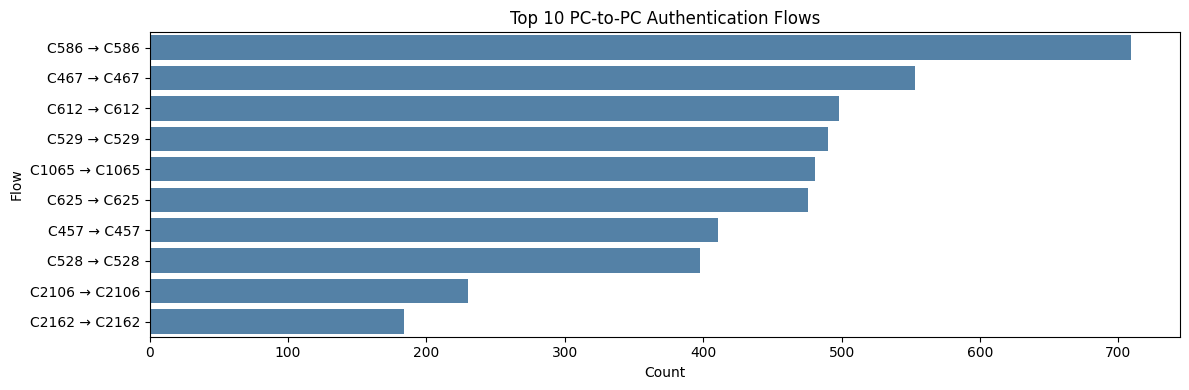

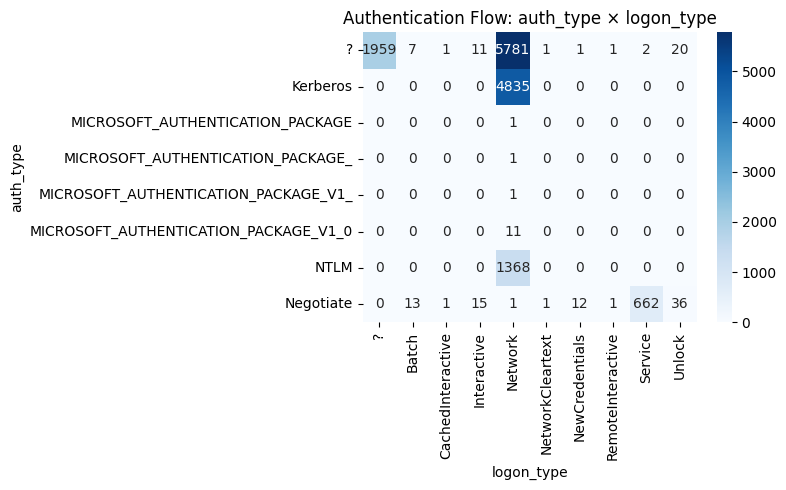

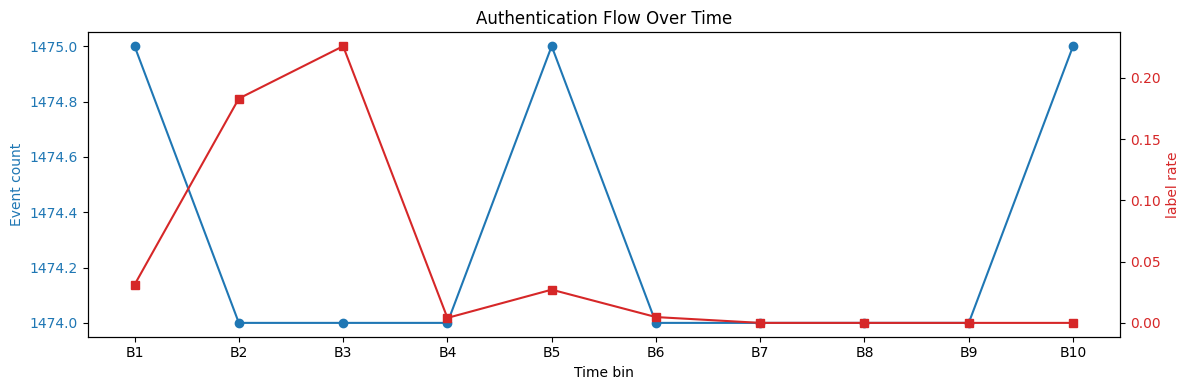

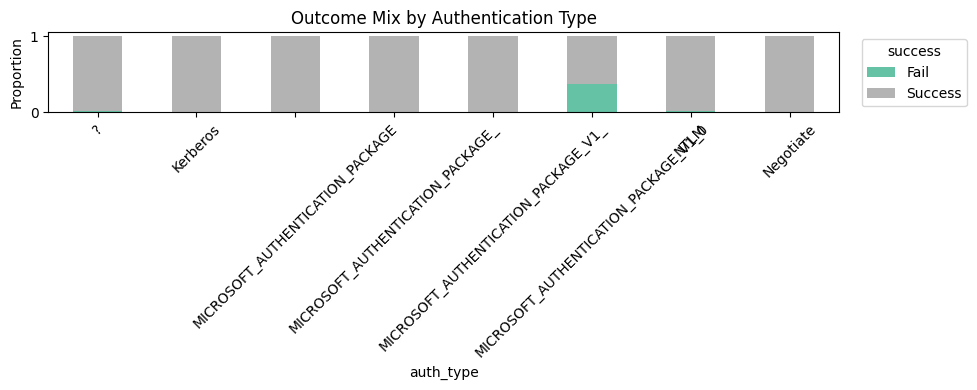

In [2]:
# Authentication flow analysis

df_flow = df.sort_values("time").copy()
label_name = label_col[0] if label_col else None

# Basic flow metrics
total_events = len(df_flow)
unique_src_users = df_flow["src_user"].nunique()
unique_dst_users = df_flow["dst_user"].nunique()
unique_src_pcs = df_flow["src_pc"].nunique()
unique_dst_pcs = df_flow["dst_pc"].nunique()
self_user_auth_ratio = (df_flow["src_user"] == df_flow["dst_user"]).mean()

print(f"Total auth events: {total_events:,}")
print(f"Unique source users: {unique_src_users:,} | destination users: {unique_dst_users:,}")
print(f"Unique source PCs: {unique_src_pcs:,} | destination PCs: {unique_dst_pcs:,}")
print(f"Self-authentication ratio (src_user == dst_user): {self_user_auth_ratio:.2%}")

# Top user-to-user and PC-to-PC flows
top_user_flows = (
    df_flow.groupby(["src_user", "dst_user"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("count")
)
top_pc_flows = (
    df_flow.groupby(["src_pc", "dst_pc"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("count")
)

print("\nTop 10 user -> user flows:")
print(top_user_flows)

print("\nTop 10 PC -> PC flows:")
print(top_pc_flows)

# Time-binned behavior (10 bins across timeline)
df_flow["time_bin"] = pd.qcut(df_flow["time"], q=10, duplicates="drop")
events_per_bin = df_flow.groupby("time_bin", observed=False).size()

if label_name:
    anomaly_rate_per_bin = df_flow.groupby("time_bin", observed=False)[label_name].mean()

# Plot 1: Top PC->PC flows
plt.figure(figsize=(12, 4))
pc_labels = [f"{s} → {d}" for s, d in top_pc_flows.index]
sns.barplot(x=top_pc_flows.values, y=pc_labels, color="steelblue")
plt.title("Top 10 PC-to-PC Authentication Flows")
plt.xlabel("Count")
plt.ylabel("Flow")
plt.tight_layout()
plt.show()

# Plot 2: Auth type vs Logon type heatmap (flow structure)
auth_logon = pd.crosstab(df_flow["auth_type"], df_flow["logon_type"])
plt.figure(figsize=(8, 5))
sns.heatmap(auth_logon, annot=True, fmt="d", cmap="Blues")
plt.title("Authentication Flow: auth_type × logon_type")
plt.tight_layout()
plt.show()

# Plot 3: Temporal volume and anomaly rate
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(events_per_bin.values, marker="o", color="tab:blue", label="Events")
ax1.set_xlabel("Time bin")
ax1.set_ylabel("Event count", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(range(len(events_per_bin)))
ax1.set_xticklabels([f"B{i+1}" for i in range(len(events_per_bin))], rotation=0)

if label_name:
    ax2 = ax1.twinx()
    ax2.plot(anomaly_rate_per_bin.values, marker="s", color="tab:red", label=f"{label_name} rate")
    ax2.set_ylabel(f"{label_name} rate", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Authentication Flow Over Time")
plt.tight_layout()
plt.show()

# Plot 4: Success distribution by auth_type
success_dist = pd.crosstab(df_flow["auth_type"], df_flow["success"], normalize="index")
success_dist.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="Set2")
plt.title("Outcome Mix by Authentication Type")
plt.ylabel("Proportion")
plt.xlabel("auth_type")
plt.xticks(rotation=45)
plt.legend(title="success", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [3]:
# Detect anomalous authentication flows (flow-level scoring)

flow_cols = ["src_user", "dst_user", "src_pc", "dst_pc", "auth_type", "logon_type"]

anomalous_flow_df = (
    df_flow.groupby(flow_cols, observed=False)
    .agg(
        flow_count=("time", "size"),
        fail_count=("success", lambda s: (s == "Fail").sum()),
        unique_bins=("time_bin", "nunique"),
        label_rate=(label_name, "mean") if label_name else ("time", "size"),
    )
    .reset_index()
)

# If label_name was not available, remove placeholder behavior
if not label_name:
    anomalous_flow_df = anomalous_flow_df.drop(columns=["label_rate"])

# Derived metrics
anomalous_flow_df["fail_rate"] = anomalous_flow_df["fail_count"] / anomalous_flow_df["flow_count"]
anomalous_flow_df["flow_freq"] = anomalous_flow_df["flow_count"] / total_events
anomalous_flow_df["rarity_score"] = -np.log(anomalous_flow_df["flow_freq"].clip(lower=1e-12))

# Composite anomaly score
if label_name:
    anomalous_flow_df["anomaly_score"] = (
        0.45 * anomalous_flow_df["rarity_score"]
        + 0.30 * anomalous_flow_df["fail_rate"]
        + 0.25 * anomalous_flow_df["label_rate"]
    )
else:
    anomalous_flow_df["anomaly_score"] = (
        0.70 * anomalous_flow_df["rarity_score"]
        + 0.30 * anomalous_flow_df["fail_rate"]
    )

# Flag top 1% highest-scoring flows
threshold = anomalous_flow_df["anomaly_score"].quantile(0.99)
anomalous_flows = anomalous_flow_df[anomalous_flow_df["anomaly_score"] >= threshold].copy()
anomalous_flows = anomalous_flows.sort_values("anomaly_score", ascending=False)

print(f"Detected anomalous flows: {len(anomalous_flows)} (threshold={threshold:.4f})")
display(
    anomalous_flows.head(20)[
        flow_cols + ["flow_count", "fail_count", "fail_rate"] + (["label_rate"] if label_name else []) + ["anomaly_score"]
    ]
)

Detected anomalous flows: 365 (threshold=4.5693)


,src_user,dst_user,src_pc,dst_pc,auth_type,logon_type,flow_count,fail_count,fail_rate,label_rate,anomaly_score
1201,C12546$@?,C12546$@?,C12546,C12546,?,?,1,1,1.0,0.0,4.619336
11489,U8510@DOM1,U8510@DOM1,C2106,C2106,Kerberos,Network,1,1,1.0,0.0,4.619336
10403,U5645@?,U5645@?,C13232,C13232,?,?,1,1,1.0,0.0,4.619336
2000,C1527$@DOM1,C1527$@DOM1,C1527,C586,NTLM,Network,1,1,1.0,0.0,4.619336
11227,U7616@?,U7616@?,C16612,C16612,?,?,1,1,1.0,0.0,4.619336
11293,U7800@DOM1,U7800@DOM1,C16955,C16955,?,?,1,1,1.0,0.0,4.619336
11307,U7865@?,U7865@?,C612,C612,?,?,1,1,1.0,0.0,4.619336
11318,U78@?,U78@?,C1727,C1727,?,?,1,1,1.0,0.0,4.619336
10324,U5405@?,U5405@?,C574,C574,?,?,1,1,1.0,0.0,4.619336
9540,U3597@?,U3597@?,C539,C539,?,?,1,1,1.0,0.0,4.619336


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

# Features for Isolation Forest (use existing df_flow and label_name)
if not label_name:
    raise ValueError("No label column found. 'label_name' is required for evaluation.")

feature_cols = [
    "time", "src_user", "dst_user", "src_pc", "dst_pc",
    "auth_type", "logon_type", "auth_orient", "success"
]

X = df_flow[feature_cols].copy()
y = df_flow[label_name].astype(int).copy()

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=X.select_dtypes(include="object").columns, dummy_na=False)

# Use label prevalence as contamination estimate (clipped for valid range)
contamination = float(np.clip(y.mean(), 0.001, 0.5))

iso = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_encoded) # Fit on entire dataset for unsupervised detection

# Predictions: -1 = anomaly, 1 = normal
y_pred = (iso.predict(X_encoded) == -1).astype(int)

# Anomaly score (higher => more anomalous)
y_score = -iso.decision_function(X_encoded)

print(f"Dataset size: {len(X_encoded):,}")
print(f"Label prevalence: {y.mean():.4f} | contamination used: {contamination:.4f}")
print("\nClassification Report:")
print(classification_report(y, y_pred, digits=4))

cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
print("Confusion Matrix:")
display(cm_df)

print(f"ROC-AUC (score-based): {roc_auc_score(y, y_score):.4f}")
print(f"PR-AUC  (score-based): {average_precision_score(y, y_score):.4f}")

/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_40981/1500083432.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_encoded = pd.get_dummies(X, columns=X.select_dtypes(include="object").columns, dummy_na=False)


Dataset size: 14,743
Label prevalence: 0.0476 | contamination used: 0.0476

Classification Report:
              precision    recall  f1-score   support

           0     0.9503    0.9503    0.9503     14041
           1     0.0057    0.0057    0.0057       702

    accuracy                         0.9053     14743
   macro avg     0.4780    0.4780    0.4780     14743
weighted avg     0.9053    0.9053    0.9053     14743

Confusion Matrix:


,Pred 0,Pred 1
Actual 0,13343,698
Actual 1,698,4


ROC-AUC (score-based): 0.5492
PR-AUC  (score-based): 0.0534


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Local Outlier Factor (LOF) + LSTM Autoencoder


# -----------------------------
# 1) Local Outlier Factor
# -----------------------------
lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination=contamination,
    metric="euclidean",
    n_jobs=-1
)

# LOF output: -1 anomaly, 1 normal
y_pred_lof = (lof.fit_predict(X_encoded) == -1).astype(int)
y_score_lof = -lof.negative_outlier_factor_  # higher => more anomalous

print("=== Local Outlier Factor ===")
print(classification_report(y, y_pred_lof, digits=4))
print(f"ROC-AUC (score-based): {roc_auc_score(y, y_score_lof):.4f}")
print(f"PR-AUC  (score-based): {average_precision_score(y, y_score_lof):.4f}")

cm_lof = confusion_matrix(y, y_pred_lof)
display(pd.DataFrame(cm_lof, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))


# -----------------------------
# 2) LSTM Autoencoder
# -----------------------------
try:

    df_seq = df_flow.sort_values("time").copy()

    # Use existing feature_cols; encode object columns to integer codes
    X_lstm_df = df_seq[feature_cols].copy()
    for c in X_lstm_df.select_dtypes(include="object").columns:
        X_lstm_df[c] = X_lstm_df[c].astype("category").cat.codes

    scaler = MinMaxScaler()
    X_lstm_scaled = scaler.fit_transform(X_lstm_df).astype("float32")

    # Build sliding windows
    window = 10
    n = len(X_lstm_scaled) - window + 1
    X_seq = np.stack([X_lstm_scaled[i:i + window] for i in range(n)], axis=0)

    # Window label = anomaly if any event in window is anomaly
    y_seq = (
        df_seq[label_name]
        .rolling(window)
        .max()
        .dropna()
        .astype(int)
        .values
    )

    # Train autoencoder only on normal windows
    X_seq_train = X_seq[y_seq == 0]
    timesteps, n_features = X_seq.shape[1], X_seq.shape[2]

    inp = Input(shape=(timesteps, n_features))
    x = LSTM(32, activation="tanh", return_sequences=False)(inp)
    x = RepeatVector(timesteps)(x)
    x = LSTM(32, activation="tanh", return_sequences=True)(x)
    out = TimeDistributed(Dense(n_features))(x)

    lstm_ae = Model(inp, out)
    lstm_ae.compile(optimizer="adam", loss="mse")

    es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    lstm_ae.fit(
        X_seq_train, X_seq_train,
        epochs=8,
        batch_size=128,
        validation_split=0.1,
        callbacks=[es],
        verbose=0
    )

    # Reconstruction error
    X_seq_hat = lstm_ae.predict(X_seq, verbose=0)
    recon_err = np.mean((X_seq - X_seq_hat) ** 2, axis=(1, 2))

    # Threshold from normal-train errors at (1 - contamination) quantile
    X_seq_train_hat = lstm_ae.predict(X_seq_train, verbose=0)
    train_err = np.mean((X_seq_train - X_seq_train_hat) ** 2, axis=(1, 2))
    thr_lstm = np.quantile(train_err, 1 - contamination)

    y_pred_lstm = (recon_err >= thr_lstm).astype(int)
    y_score_lstm = recon_err

    print("\n=== LSTM Autoencoder (window-level) ===")
    print(classification_report(y_seq, y_pred_lstm, digits=4))
    print(f"ROC-AUC (score-based): {roc_auc_score(y_seq, y_score_lstm):.4f}")
    print(f"PR-AUC  (score-based): {average_precision_score(y_seq, y_score_lstm):.4f}")

    cm_lstm = confusion_matrix(y_seq, y_pred_lstm)
    display(pd.DataFrame(cm_lstm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

except Exception as e:
    print("LSTM step skipped. TensorFlow/Keras is not available or failed to run.")
    print("Error:", e)